In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json

from tune_diagram import TuneDiagram, SweepTrajectory

In [2]:
def remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2):
    "Remove apertures of off-momentum BPMs which give flanges as bottlenecks"
    tt = line.get_table()
    tw = line.twiss()
    mask_disp = 5*np.sqrt(tw.betx*exn*pmass/nrj)+n_buckets*bucket_height*tw.dx > 0.025
    mask_bpm = ['bp' in name for name in tt.name]
    mask_aper = np.array(['aper' in name for name in tt.name])
    offmom_bpms = tt.name[mask_disp & mask_bpm & ~mask_aper]
    aper_to_remove = [f'{name}{suffix}' for name in offmom_bpms for suffix in ('.a_aper', '.b_aper')]
    line.remove(aper_to_remove)

In [3]:
error_variants = {
    'dipole_b3' : [0, 0, 1, 0, 0, 0],
    'dipole_b5' : [0, 0, 0, 0, 1, 0],
    'dipole_b3b5': [0, 0, 1, 0, 1, 0],
    'quadrupole_b4': [0, 0, 0, 1, 0, 0],
    'quadrupole_b6': [0, 0, 0, 0, 0, 1],
    'quadrupole_b4b6': [0, 0, 0, 1, 0, 1],
    'dipole_b3_quadrupole_b4': [0, 0, 1, 1, 0, 0],
    'all': [0, 0, 1, 1, 1, 1]
}
error_variant_name = 'all'
qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

In [4]:
# line = xt.Line.from_json('../injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
line = xt.Line.from_json('../../injection_lines/sps_q20_inj.json')
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

tw = line.twiss()
# remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2)

# Installing errors
b1, b2, b3, b4, b5, b6 = error_variants[error_variant_name]
tte = env.elements.get_table()
mask_rbends = tte.element_type == 'RBend'
mask_quads = tte.element_type == 'Quadrupole'
mask_sextupoles = tte.element_type == 'Sextupole'

mba = tte.rows[mask_rbends].rows['mba.*'].name
mbb = tte.rows[mask_rbends].rows['mbb.*'].name
qf = tte.rows[mask_quads].rows['qf.*'].name
qd = tte.rows[mask_quads].rows['qd.*'].name
lsf = tte.rows[mask_sextupoles].rows['lsf.*'].name
lsd = tte.rows[mask_sextupoles].rows['lsd.*'].name

env.vars['qph_setvalue'] = 0.0
env.vars['qpv_setvalue'] = 0.0

# Set the strengths according to Hannes' measurements
for nn in mba:
    env[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3, b4*0., b5*-5.74, b6*0.])

for nn in mbb:
    env[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3, b4*0., b5*-5.10, b6*0.])

for nn in qf:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*0.75e-1, b5*0., b6*-0.87e3])

for nn in qd:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*-2.03e-1, b5*0., b6*2.04e3])

env.vars['qph_setvalue'] = xi_x
env.vars['qpv_setvalue'] = xi_y
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
    ])

Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 13.73                             
Matching: model call n. 7 penalty = 2.6216e-03              
Optimize - end penalty:  0.00262155                            


In [5]:
# line = xt.Line.from_json('../injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
line2 = xt.Line.from_json('../../injection_lines/sps_q20_inj.json')
env2 = line2.env
cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line2['actcse.31632'].voltage = 3.0e6

tw2 = line2.twiss()

qx = 19.87
qy = 19.82
xi_x = 0.5
xi_y = 0.5
# remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2)

# Installing errors
b1, b2, b3, b4, b5, b6 = error_variants[error_variant_name]
tte2 = env2.elements.get_table()
mask_rbends = tte2.element_type == 'RBend'
mask_quads = tte2.element_type == 'Quadrupole'
mask_sextupoles = tte2.element_type == 'Sextupole'

mba = tte2.rows[mask_rbends].rows['mba.*'].name
mbb = tte2.rows[mask_rbends].rows['mbb.*'].name
qf = tte2.rows[mask_quads].rows['qf.*'].name
qd = tte2.rows[mask_quads].rows['qd.*'].name
lsf = tte2.rows[mask_sextupoles].rows['lsf.*'].name
lsd = tte2.rows[mask_sextupoles].rows['lsd.*'].name

env2.vars['qph_setvalue'] = 0.0
env2.vars['qpv_setvalue'] = 0.0

# Set the strengths according to Hannes' measurements
for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3, b4*0., b5*-5.74, b6*0.])

for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3, b4*0., b5*-5.10, b6*0.])

for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0., b4*0.75e-1, b5*0., b6*-0.87e3])

for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0., b4*-2.03e-1, b5*0., b6*2.04e3])

env2.vars['qph_setvalue'] = xi_x
env2.vars['qpv_setvalue'] = xi_y
opt = line2.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
    ])

Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 14.64                             
Matching: model call n. 13 penalty = 7.6132e-04              
Optimize - end penalty:  0.000761316                            


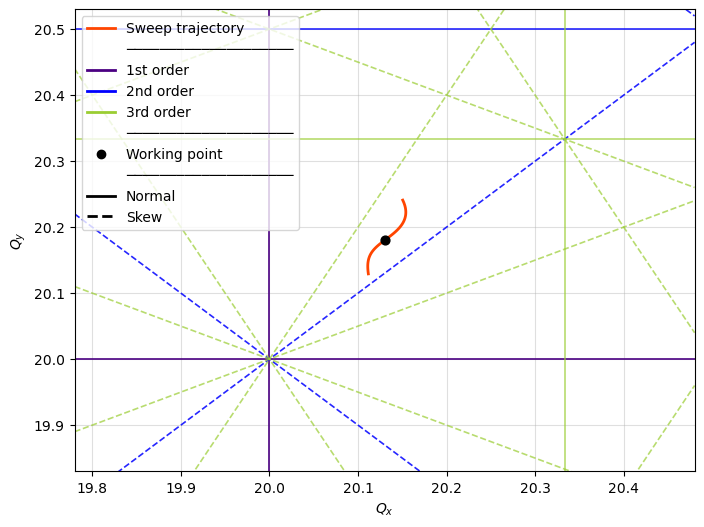

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

td = TuneDiagram(qx0=20.13, qy0=20.18, half_range=0.35, max_order=3, skew=True)
td.plot(ax=ax)
s = SweepTrajectory.from_twiss_scan(
    line=line,
    delta_range=(-4e-3, 4e-3), step=1e-4, use_fractional=False, verbose=True,
)
td.finalize(ax, extra_handles=[s.plot(ax)],
             xlabel=r"$Q_x$", ylabel=r"$Q_y$")

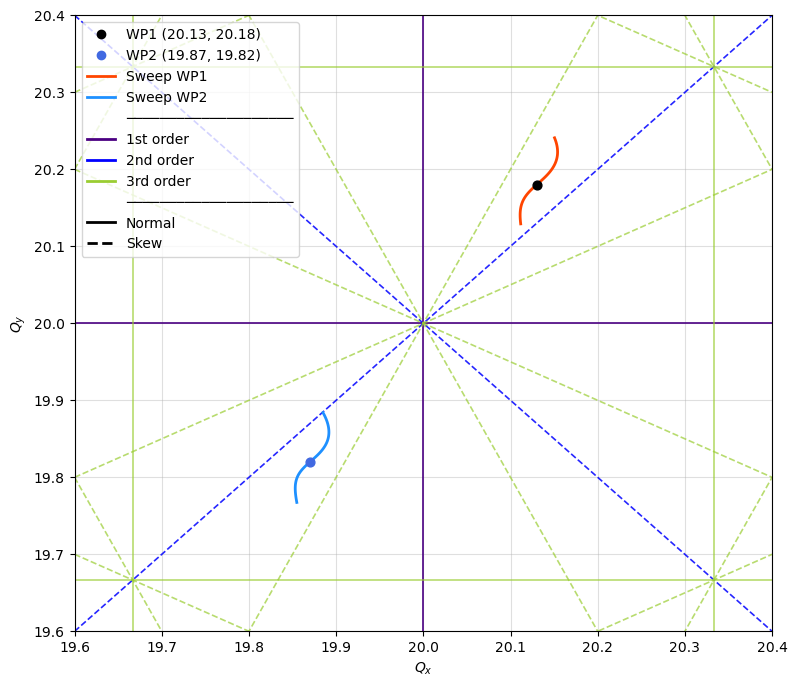

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 8))

td = TuneDiagram(qx0=20.00, qy0=20.00, half_range=0.4, max_order=3, skew=True)
td.plot(ax=ax, show_working_point=False) #working point will be plotted separately to be able to show both on the same plot

ax.scatter(20.13, 20.18, color="k",         zorder=5, s=40)
ax.scatter(19.87, 19.82, color="royalblue", zorder=5, s=40)

s1 = SweepTrajectory.from_twiss_scan(line=line, delta_range=(-4e-3, 4e-3), step=1e-4)
s2 = SweepTrajectory.from_twiss_scan(line=line2, delta_range=(-4e-3, 4e-3), step=1e-4)

h_wp1 = mlines.Line2D([], [], color="k",         marker="o", ls="None", markersize=6, label="WP1 (20.13, 20.18)")
h_wp2 = mlines.Line2D([], [], color="royalblue", marker="o", ls="None", markersize=6, label="WP2 (19.87, 19.82)")
h_s1  = s1.plot(ax, color="orangered",  label="Sweep WP1")
h_s2  = s2.plot(ax, color="dodgerblue", label="Sweep WP2")

td.finalize(ax, extra_handles=[h_wp1, h_wp2, h_s1, h_s2], xlabel=r"$Q_x$", ylabel=r"$Q_y$")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(s1.delta, s1.qy, color="orangered", label="(Qx, Qy) = (20.13, 20.18)")

array([20.11166999, 20.11148861, 20.11133483, 20.11120989, 20.11111495,
       20.11105105, 20.11101917, 20.11102018, 20.11105487, 20.11112394,
       20.11122798, 20.11136752, 20.11154299, 20.1117547 , 20.11200292,
       20.1122878 , 20.1126094 , 20.11296771, 20.1133626 , 20.11379389,
       20.11426129, 20.11476442, 20.11530283, 20.11587597, 20.11648321,
       20.11712384, 20.11779706, 20.11850198, 20.11923766, 20.12000303,
       20.12079698, 20.12161829, 20.12246569, 20.12333781, 20.1242332 ,
       20.12515036, 20.12608769, 20.12704351, 20.1280161 , 20.12900361,
       20.13000418, 20.13101583, 20.13203654, 20.1330642 , 20.13409663,
       20.13513159, 20.13616677, 20.13719978, 20.13822818, 20.13924946,
       20.14026101, 20.14126021, 20.14224431, 20.14321056, 20.14415608,
       20.14507796, 20.14597323, 20.14683882, 20.14767162, 20.14846845,
       20.14922604, 20.14994109, 20.15061019, 20.15122989, 20.15179665,
       20.15230687, 20.15275687, 20.1531429 , 20.15346114, 20.15

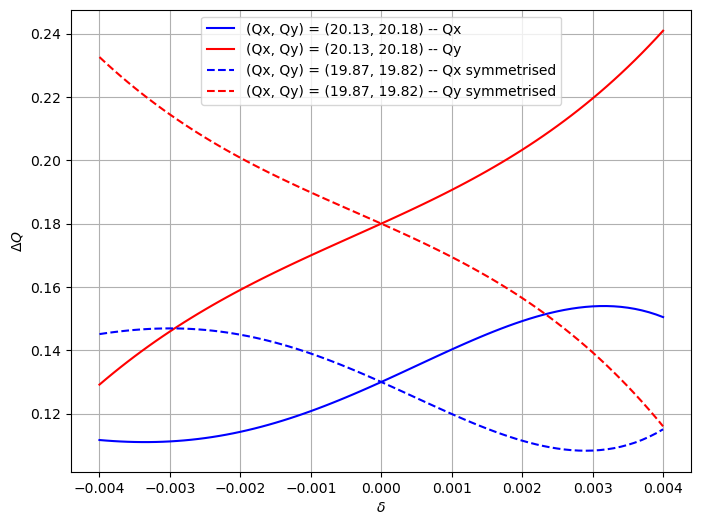

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
deltas = np.linspace(-4e-3, 4e-3, len(s1.qx))
ax.plot(deltas, s1.qx -20, color="blue", label="(Qx, Qy) = (20.13, 20.18) -- Qx")
ax.plot(deltas, s1.qy-20, color="red", label="(Qx, Qy) = (20.13, 20.18) -- Qy")
ax.plot(deltas, abs(s2.qx -20), ls = '--', color="blue", label="(Qx, Qy) = (19.87, 19.82) -- Qx symmetrised")
ax.plot(deltas, abs(s2.qy-20), ls = '--', color="red", label="(Qx, Qy) = (19.87, 19.82) -- Qy symmetrised")
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$\Delta Q$')
ax.grid()
ax.legend()

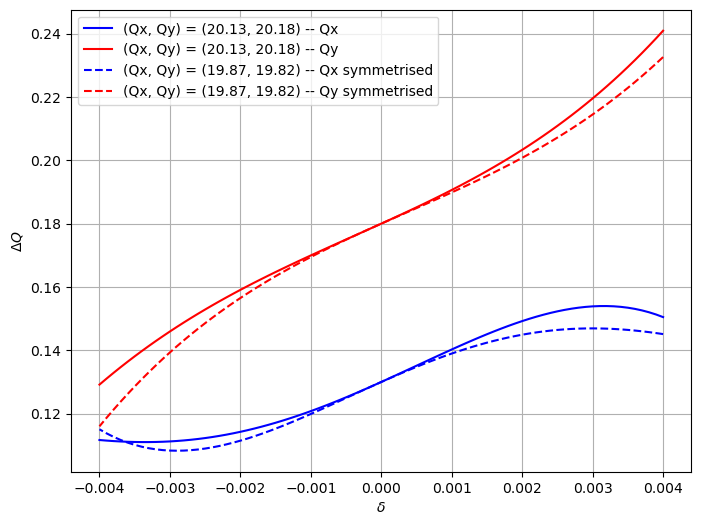

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
deltas = np.linspace(-4e-3, 4e-3, len(s1.qx))
ax.plot(deltas, s1.qx -20, color="blue", label="(Qx, Qy) = (20.13, 20.18) -- Qx")
ax.plot(deltas, s1.qy-20, color="red", label="(Qx, Qy) = (20.13, 20.18) -- Qy")
ax.plot(-deltas, abs(s2.qx -20), ls = '--', color="blue", label="(Qx, Qy) = (19.87, 19.82) -- Qx symmetrised")
ax.plot(-deltas, abs(s2.qy-20), ls = '--', color="red", label="(Qx, Qy) = (19.87, 19.82) -- Qy symmetrised")
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$\Delta Q$')
ax.grid()
ax.legend()